# Compare R137 / W138 dihedral state (v2)

v2 goals:
- No GUI (no tkinter)
- Load trajectories from the index CSV
- Cache per-simulation CSVs for expensive dihedral calculations
- Reproduce time-trace + histogram plots and the binarized timeline summary


In [18]:
# Parameters (paper mode: always run both analyses)

import os
import re
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
if (_cwd / "src").is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / "src").is_dir():
    REPO_ROOT = _cwd.parent
else:
    REPO_ROOT = Path(os.getenv("MD_REPO_ROOT", _cwd)).resolve()

SRC_DIR = REPO_ROOT / "src"
if SRC_DIR.is_dir() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Index CSV
if "MD_INDEX_CSV" in os.environ:
    INDEX_CSV = Path(os.environ["MD_INDEX_CSV"]).expanduser().resolve()
else:
    _candidates = [
        Path(r"D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/FtsW Manuscript/Anton_SimulationIndex20260413.csv"),
        REPO_ROOT / "data" / "trajectory_index.csv",
    ]
    INDEX_CSV = next((p.resolve() for p in _candidates if p.exists()), _candidates[-1].resolve())

OUT_ROOT = Path(os.getenv("MD_OUT_ROOT", INDEX_CSV.parent)).expanduser().resolve()

FORCE_RECOMPUTE = False
BUILD_17FULL = True


def _load_sim_list(path: Path) -> list[str]:
    sims: list[str] = []
    txt = path.read_text(encoding="utf-8")
    for raw in txt.splitlines():
        s = raw.strip()
        if not s:
            continue
        if s == ".":
            continue
        s = re.sub(r"[\s\.,;]+$", "", s)
        if s:
            sims.append(s)
    return sims


# Curated paper sim lists
# Use env var flag:
# - MD_PAPER_SIMSET=main (default)
# - MD_PAPER_SIMSET=revisions
PAPER_SIMSET = os.getenv("MD_PAPER_SIMSET", "main").strip().lower()
CURATED_DIR = (REPO_ROOT / "notebooks" / "curated").resolve()

if PAPER_SIMSET == "revisions":
    PAPER_LIST_FILE = (CURATED_DIR / "paper_revisions.txt").resolve()
else:
    PAPER_LIST_FILE = (CURATED_DIR / "paper_main.txt").resolve()

PAPER_SIM_LIST = _load_sim_list(PAPER_LIST_FILE)

# Default metadata encoded from the legacy JSONs (portable defaults)
# Both analyses use the curated sim list above.
DEFAULT_ANALYSES = [
    {
        "var_name": "R137 Psi Angle",
        "short_var_name": "R137_Psi_Angle",
        "resi": 137,
        "angle_type": "Psi",
        "plot_list": PAPER_SIM_LIST,
        "x_lim": (-420, 420),
        "max_hist": 0.4,
        "scale": 2.6,
        "out_dir": str((OUT_ROOT / "R137_Psi_Angle").resolve()),
    },
    {
        "var_name": "W138 Chi1 Angle",
        "short_var_name": "W138_Chi1_Angle",
        "resi": 138,
        "angle_type": "Chi1",
        "plot_list": PAPER_SIM_LIST,
        "x_lim": (-120, 120),
        "max_hist": 0.5197639069264535,
        "scale": 2.6,
        "out_dir": str((OUT_ROOT / "W138_Chi1_Angle").resolve()),
    },
]

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"INDEX_CSV: {INDEX_CSV}")
print(f"OUT_ROOT:  {OUT_ROOT}")
print(f"PAPER_SIMSET: {PAPER_SIMSET}")
print(f"PAPER_LIST_FILE: {PAPER_LIST_FILE}")
print(f"PAPER_SIM_LIST (n={len(PAPER_SIM_LIST)}): {PAPER_SIM_LIST}")


REPO_ROOT: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics
INDEX_CSV: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
OUT_ROOT:  D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript
PAPER_SIMSET: main
PAPER_LIST_FILE: D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics\notebooks\curated\paper_main.txt
PAPER_SIM_LIST (n=10): ['8', '14', '14b', '15', '15b', '17full', '42', '43', '43b', '43c']


In [19]:
# Imports

from traj_utils import validate_traj_index, read_trajectories
from dihedral_analysis import (
    compute_single_residue_dihedral,
    write_dihedral_csv,
    build_17full_dihedral_csv,
    DihedralPlotStyle,
    plot_dihedral_trace_hist,
    AngleRangeSummaryStyle,
    plot_angle_range_summary,
)


In [20]:
# Analysis definitions (from portable defaults)

analyses = []
for a in DEFAULT_ANALYSES:
    # normalize and resolve out_dir
    a2 = dict(a)
    a2["plot_list"] = [str(x) for x in a2.get("plot_list", [])]
    a2["out_dir"] = Path(a2["out_dir"]).expanduser().resolve()
    analyses.append(a2)

for a in analyses:
    print(
        f"{a['short_var_name']}: resi={a['resi']} angle={a['angle_type']} n_sims={len(a['plot_list'])} out_dir={a['out_dir']}"
    )


R137_Psi_Angle: resi=137 angle=Psi n_sims=10 out_dir=D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\R137_Psi_Angle
W138_Chi1_Angle: resi=138 angle=Chi1 n_sims=10 out_dir=D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\W138_Chi1_Angle


In [21]:
# Load trajectories (union of sims needed for both analyses)

valid_df = validate_traj_index(str(INDEX_CSV))

sims_union = []
for a in analyses:
    sims_union.extend(a["plot_list"])

# stable unique (preserve order)
raw_sims = list(dict.fromkeys([str(s) for s in sims_union]))

# Expand derived dataset '17full' into its underlying segments for trajectory loading.
# (The merged 17full CSV is built later from per-segment CSVs.)
sims_to_load = []
for s in raw_sims:
    if s == "17full":
        if BUILD_17FULL:
            sims_to_load.extend(["17", "17ext"])
        else:
            sims_to_load.append("17")
        continue
    sims_to_load.append(s)

# stable unique again after expansion
sims_to_load = list(dict.fromkeys(sims_to_load))

u_list, label_list, tf_list = read_trajectories(valid_df, sims_to_load)

# helper to map sim -> universe/time_factor in our loaded subset
sim_to_idx = {s: i for i, s in enumerate(sims_to_load)}
print(f"Loaded {len(u_list)} sims")


Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/36_kpn_S1S3_Mg_310K/p000-004_p088-92_clean.dcd
Missing system file (PSF): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.pdb
Missing trajectory file (DCD): D:/Xiao Lab Dropbox/Lab Members/Yehya_Nico/Projects/MDfolder/Cell_Division_Projects/Rockfish_NAMD/37_ccr_S1S3_Mg_310K/p000-004_p096-100_clean.dcd
D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\FtsW Manuscript\Anton_SimulationIndex20260413.csv
reading: 8
8: 4202 frames, 1008.48 ns
reading: 14
14: 4200 frames, 1008.0 ns
reading: 14b
14b: 4200 frames, 1008.0 ns
reading: 15
15: 4200 frames, 1008.0 ns
reading: 15b
15b: 4200 frames, 100

In [22]:
# Compute/cache CSVs for both analyses

# FtsW segid overrides from the v1 notebook
FTSW_SEL_BY_SIM = {
    "42": "segid PAG1",
    "43": "segid PAU1",
    "43b": "segid PAU1",
    "43c": "segid PAU1",
}

all_data = {}  # short_var_name -> {sim -> csv_path}

for a in analyses:
    var_name = a["var_name"]
    short_var_name = a["short_var_name"]
    resi = int(a["resi"])
    angle_type = a["angle_type"]
    plot_list = a["plot_list"]
    out_dir = Path(a["out_dir"]).expanduser().resolve()
    out_dir.mkdir(parents=True, exist_ok=True)

    # Expand derived dataset '17full' into its underlying segments for computation.
    sims_for_compute = []
    for s in plot_list:
        if s == "17full":
            if BUILD_17FULL:
                sims_for_compute.extend(["17", "17ext"])
            else:
                sims_for_compute.append("17")
        else:
            sims_for_compute.append(s)
    sims_for_compute = list(dict.fromkeys(sims_for_compute))

    data_dict = {}
    for sim_number in sims_for_compute:
        out_csv_path = out_dir / f"{sim_number}_{short_var_name}.csv"
        if out_csv_path.exists() and not FORCE_RECOMPUTE:
            data_dict[sim_number] = str(out_csv_path)
            continue

        if sim_number not in sim_to_idx:
            print(f"[{short_var_name}] Skipping {sim_number}: not loaded")
            continue

        i = sim_to_idx[sim_number]
        u = u_list[i]
        tf = float(tf_list[i])

        ftsw_sel = FTSW_SEL_BY_SIM.get(sim_number, "segid PROD")

        try:
            wrapped, unwrapped = compute_single_residue_dihedral(
                u, resi=resi, angle_type=angle_type, ftsw_sel=ftsw_sel
            )
            write_dihedral_csv(
                time_factor=tf,
                out_path=out_csv_path,
                var_name=var_name,
                wrapped=wrapped,
                unwrapped=unwrapped,
            )
            data_dict[sim_number] = str(out_csv_path)
        except Exception as e:
            print(f"[{short_var_name}] Skipping {sim_number}: {type(e).__name__}: {e}")

    # optional: build 17full
    if BUILD_17FULL and ("17" in data_dict) and ("17ext" in data_dict):
        out_path = out_dir / f"17full_{short_var_name}.csv"
        if (not out_path.exists()) or FORCE_RECOMPUTE:
            build_17full_dihedral_csv(
                csv_17=data_dict["17"],
                csv_17ext=data_dict["17ext"],
                out_path=out_path,
            )
        data_dict["17full"] = str(out_path)

    all_data[short_var_name] = data_dict
    print(f"[{short_var_name}] Cached CSVs: {len(data_dict)}")


[R137_Psi_Angle] Cached CSVs: 12
[W138_Chi1_Angle] Cached CSVs: 12


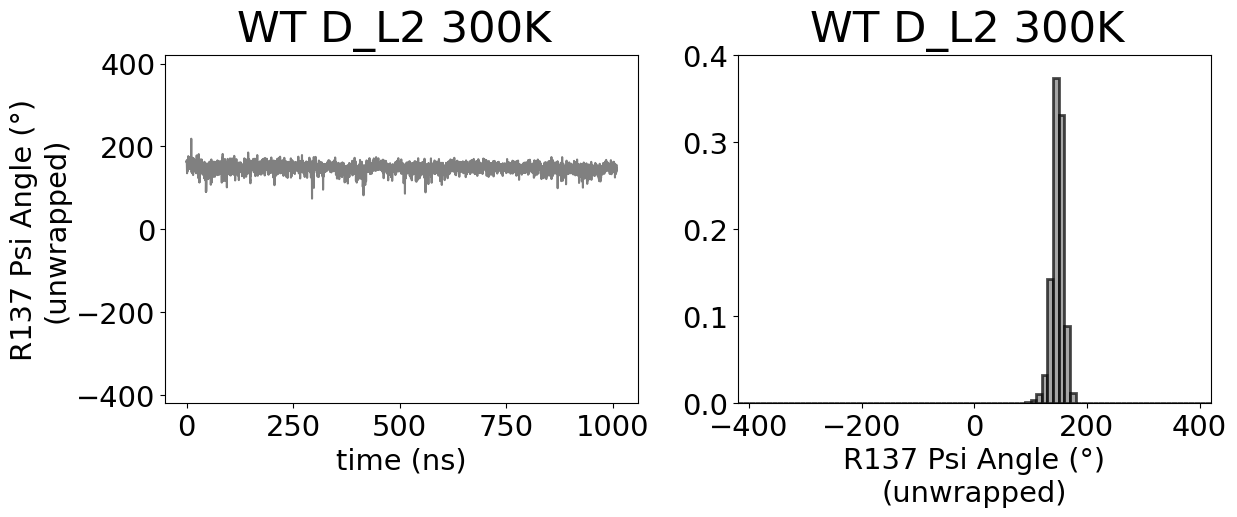

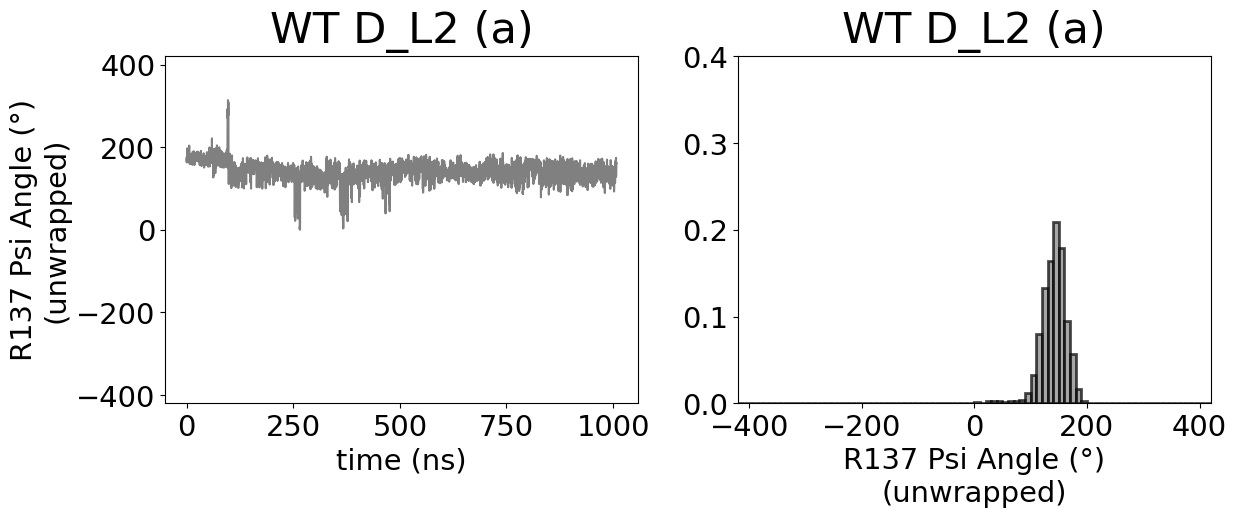

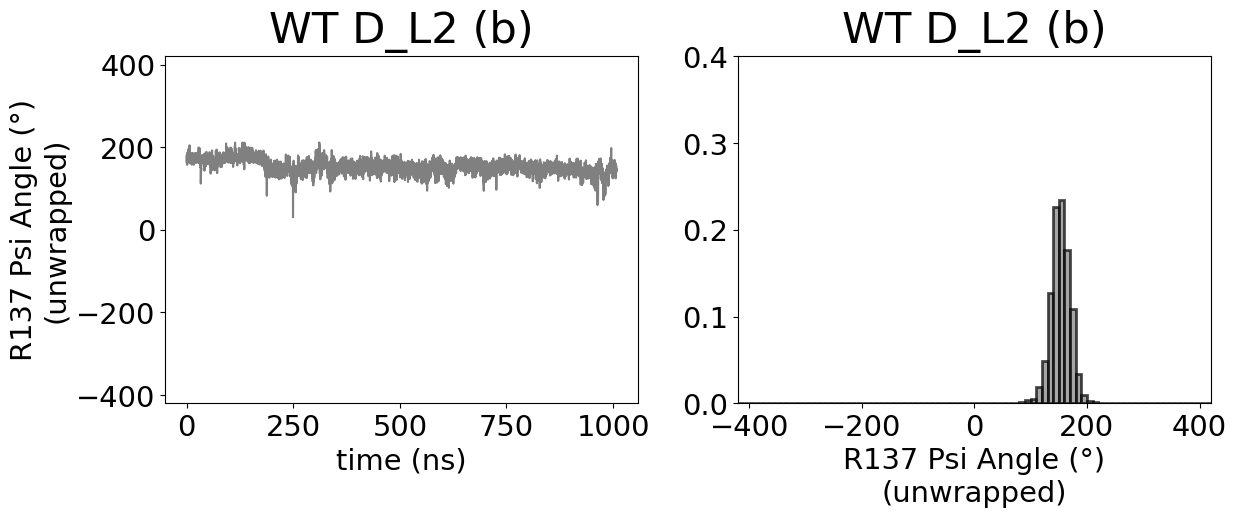

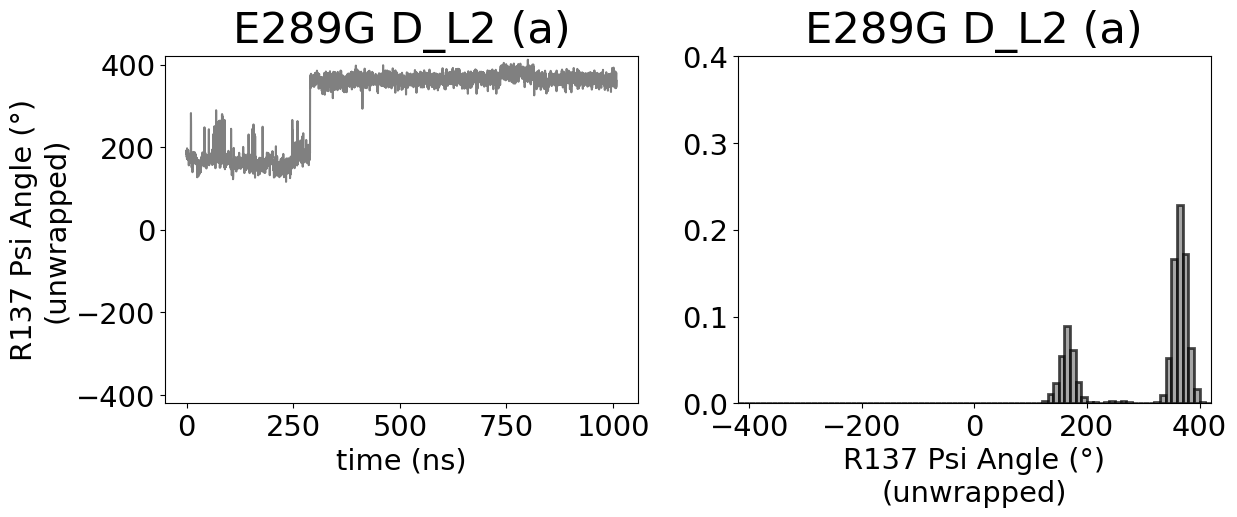

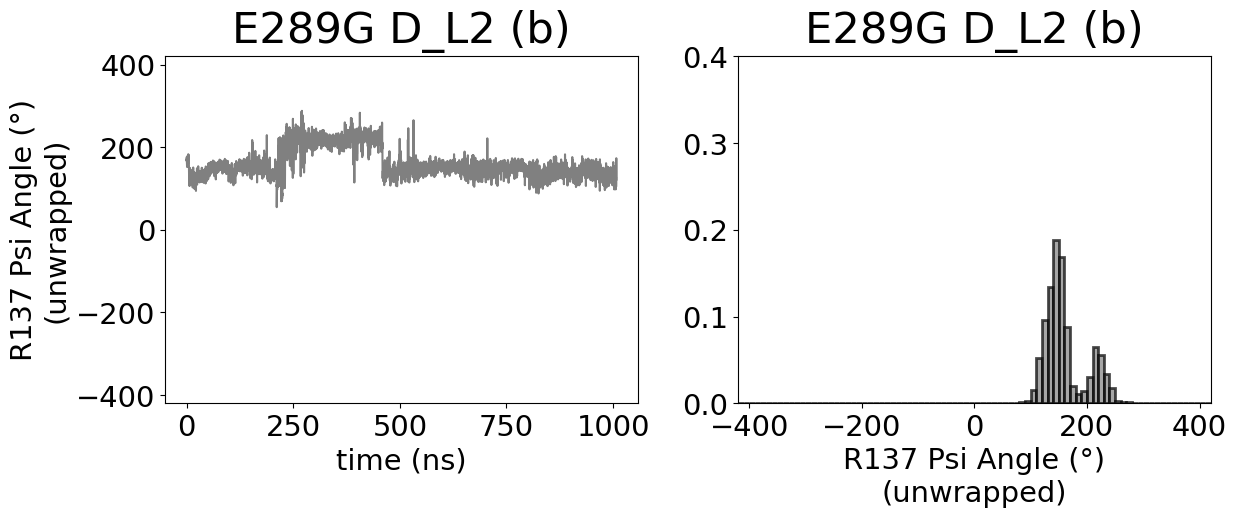

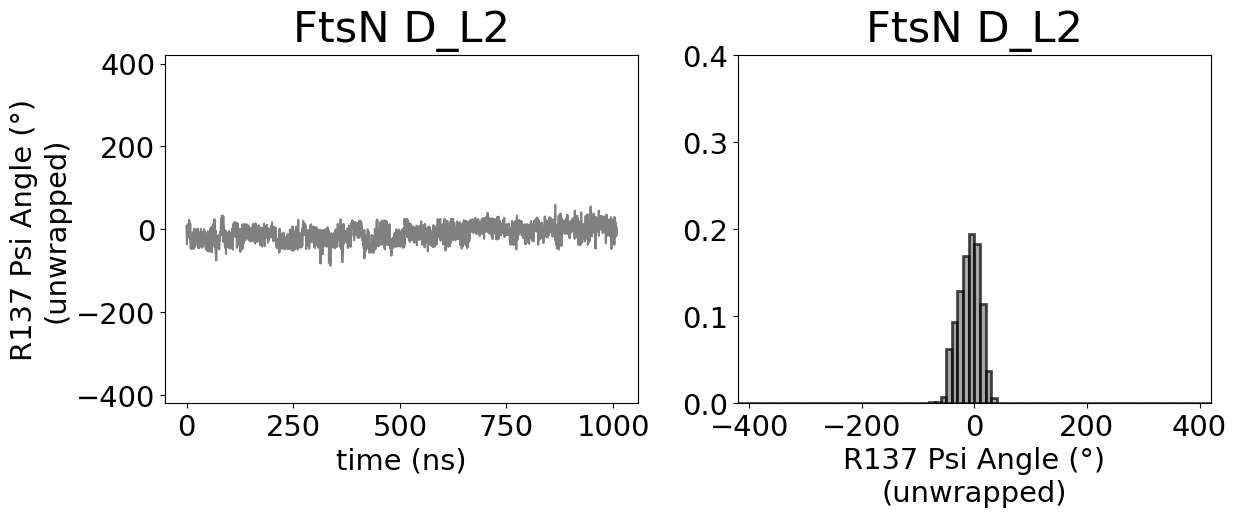

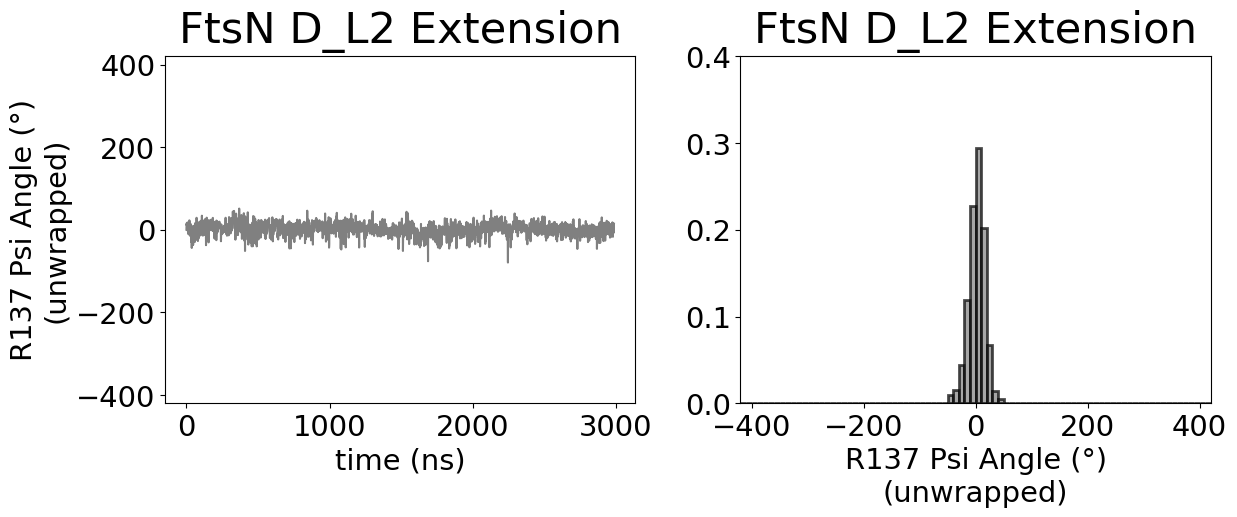

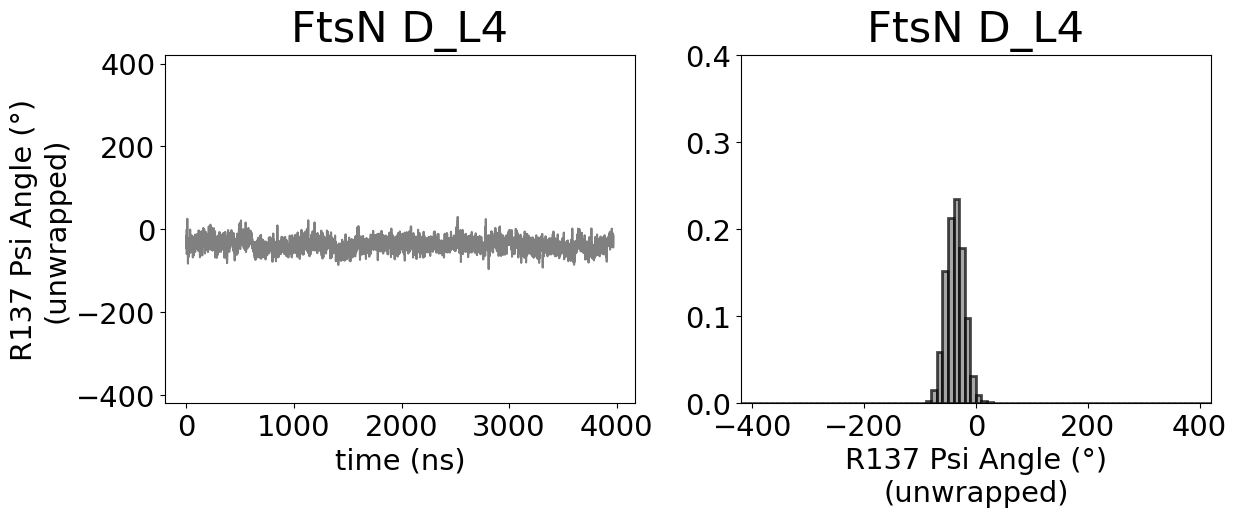

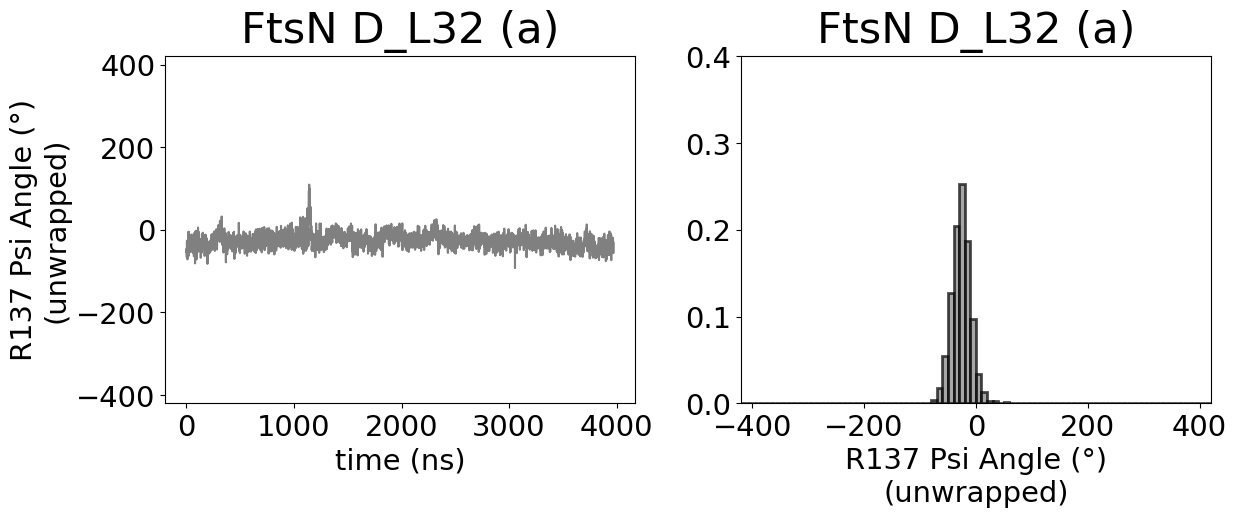

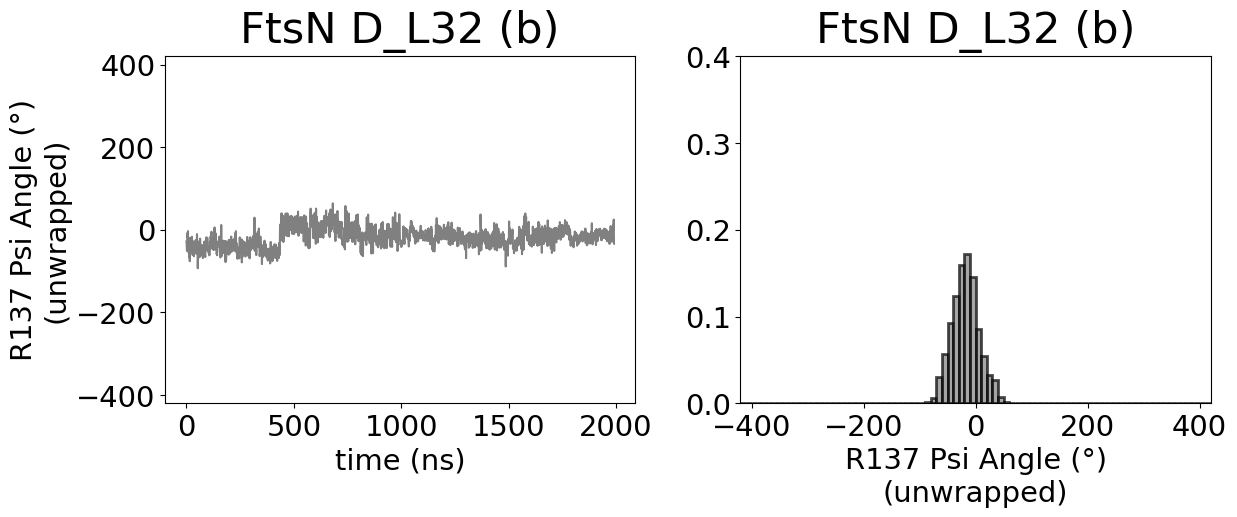

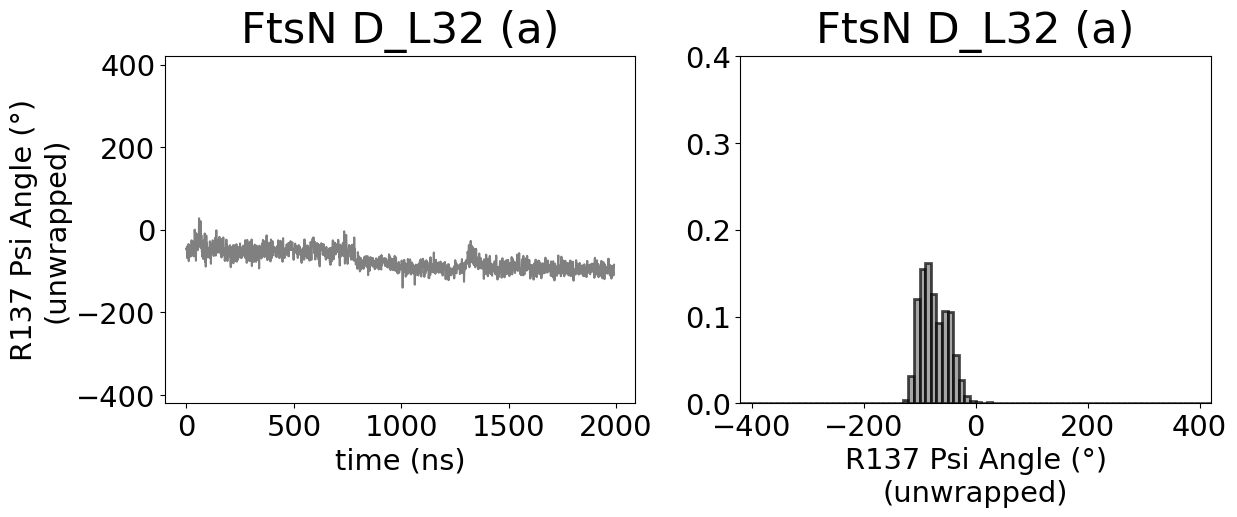

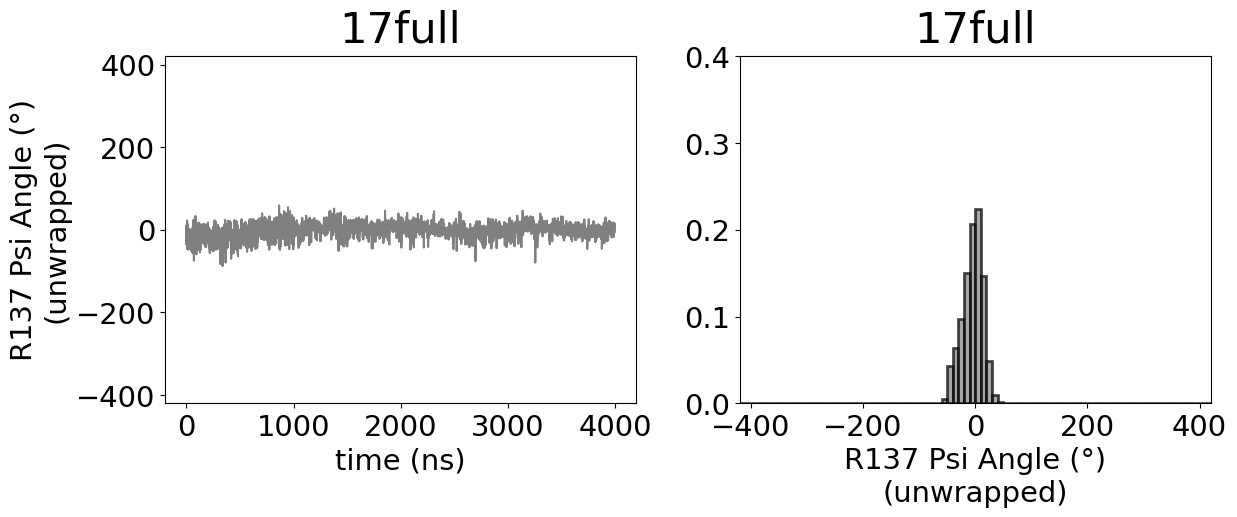

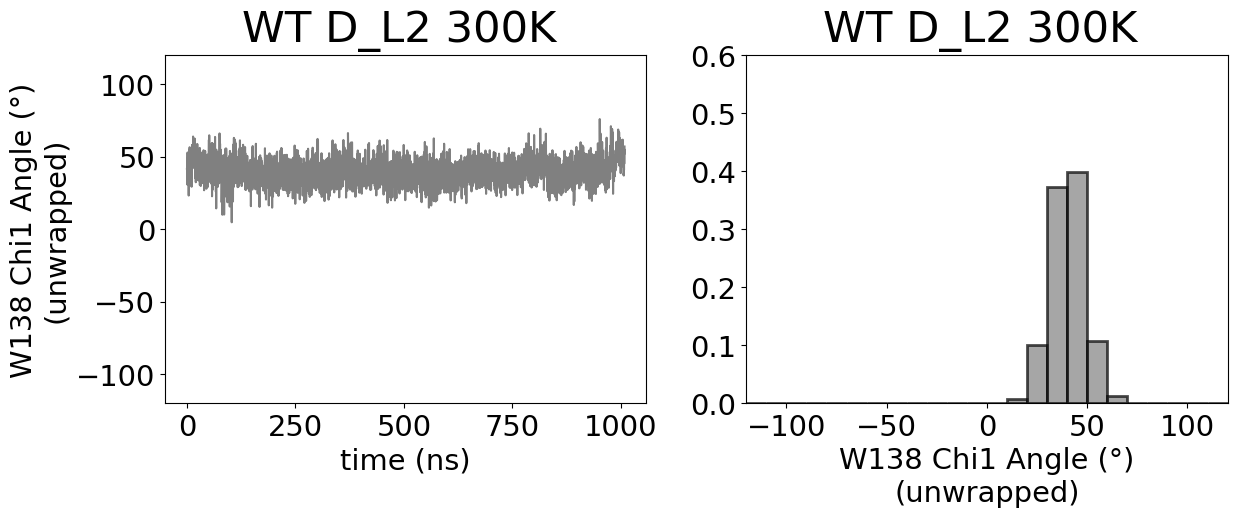

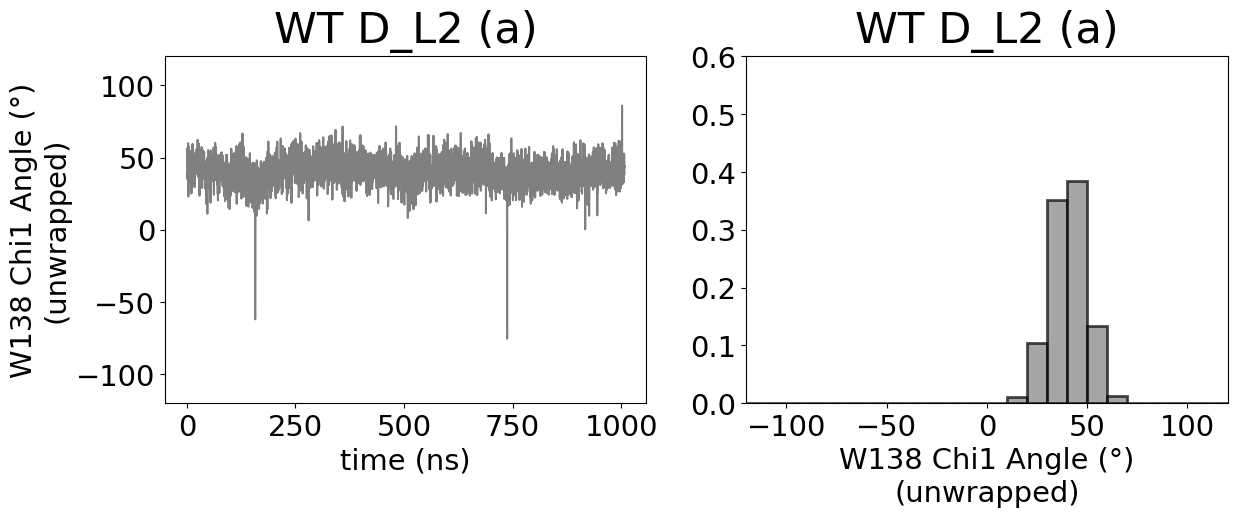

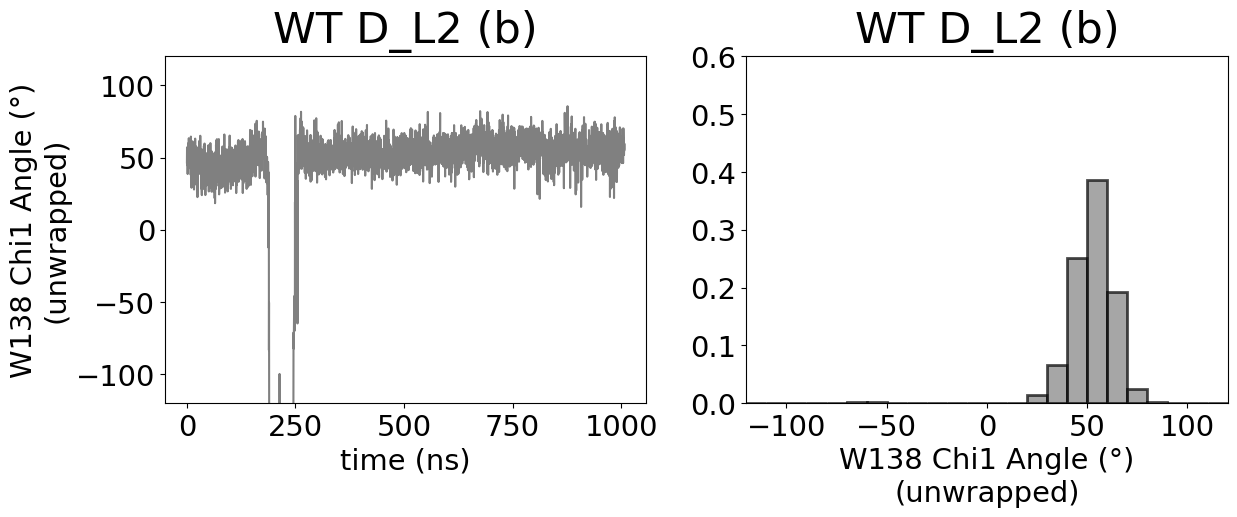

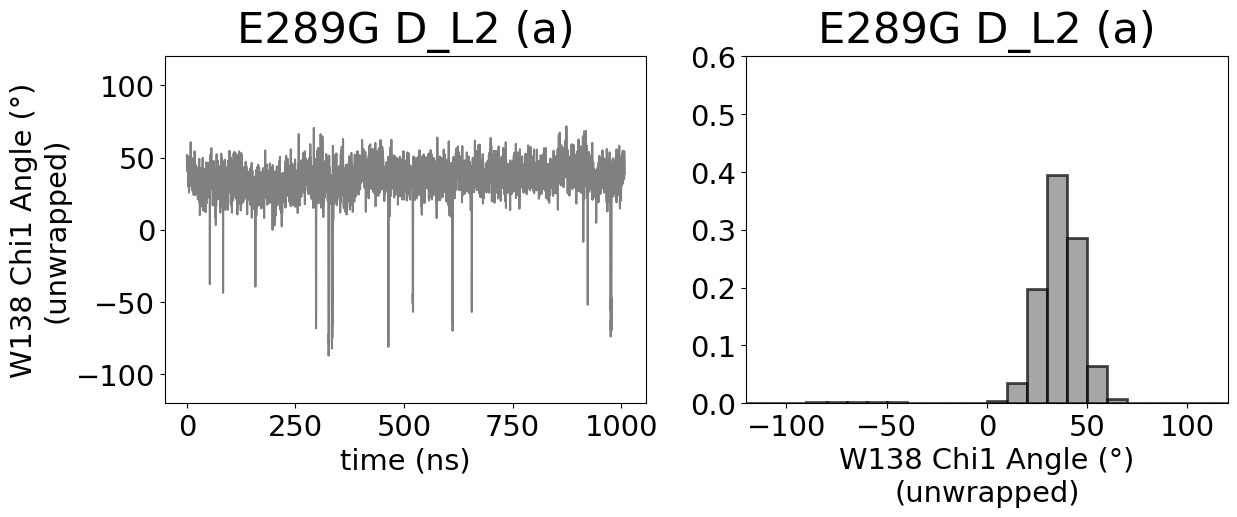

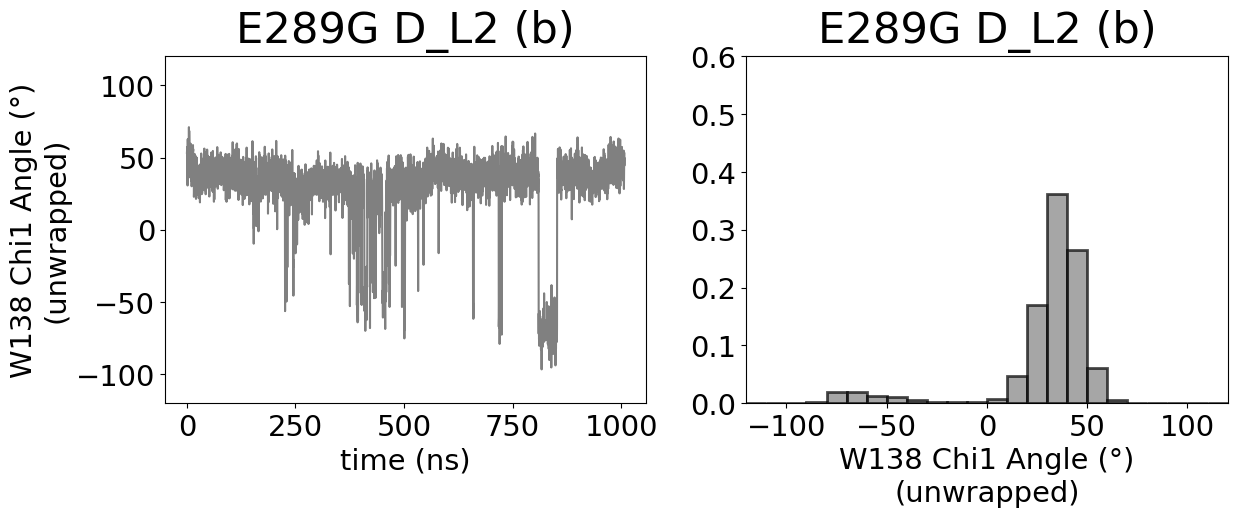

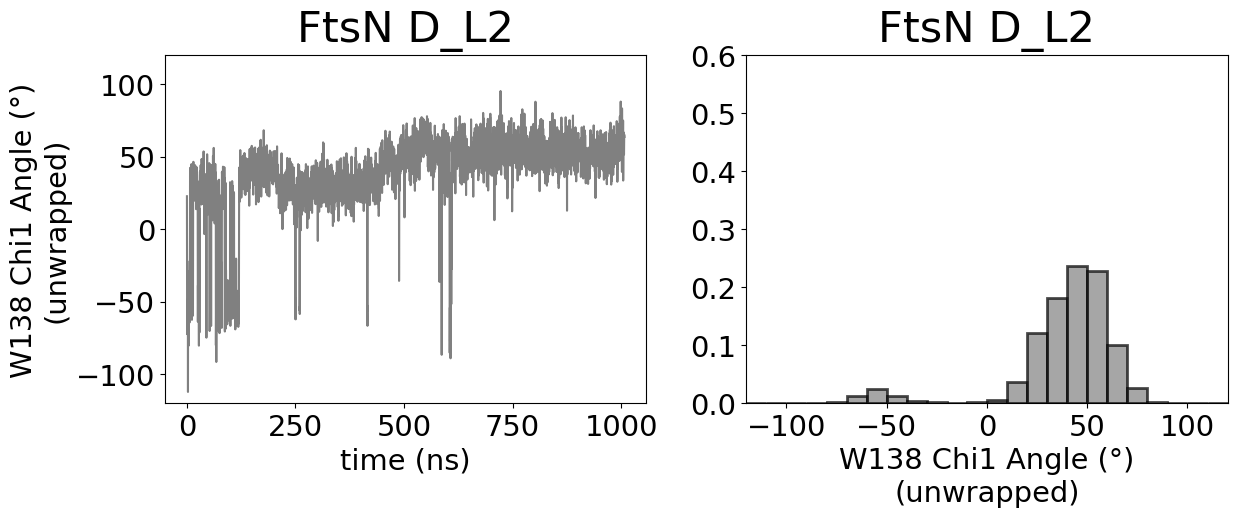

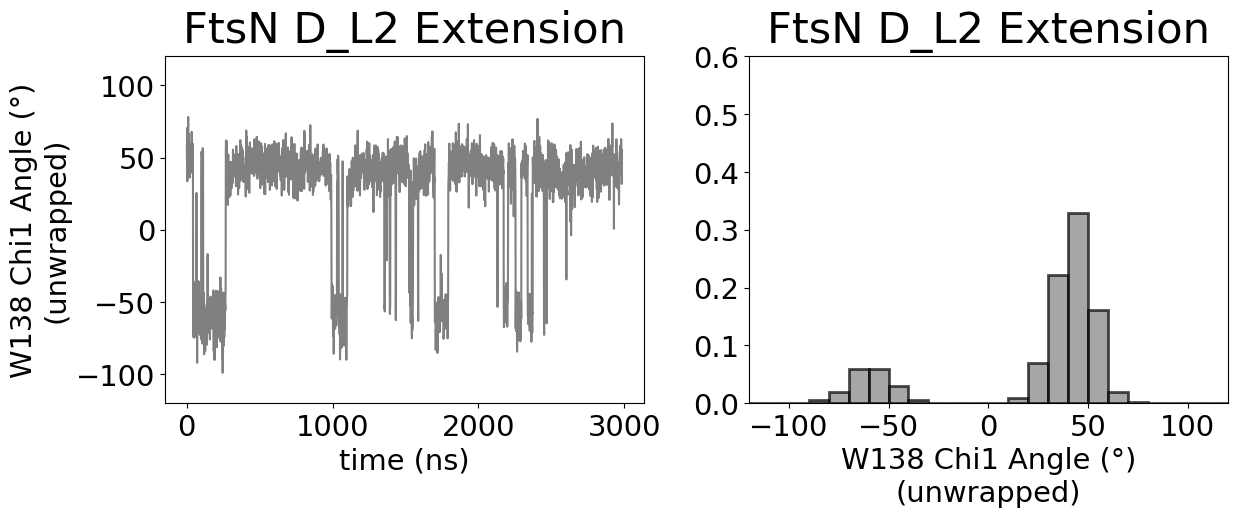

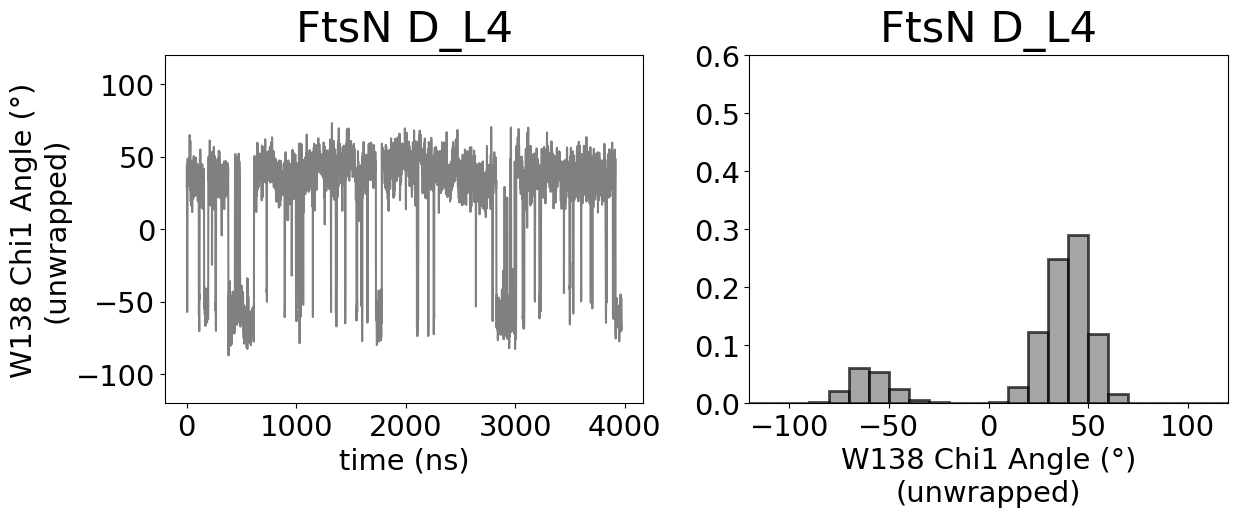

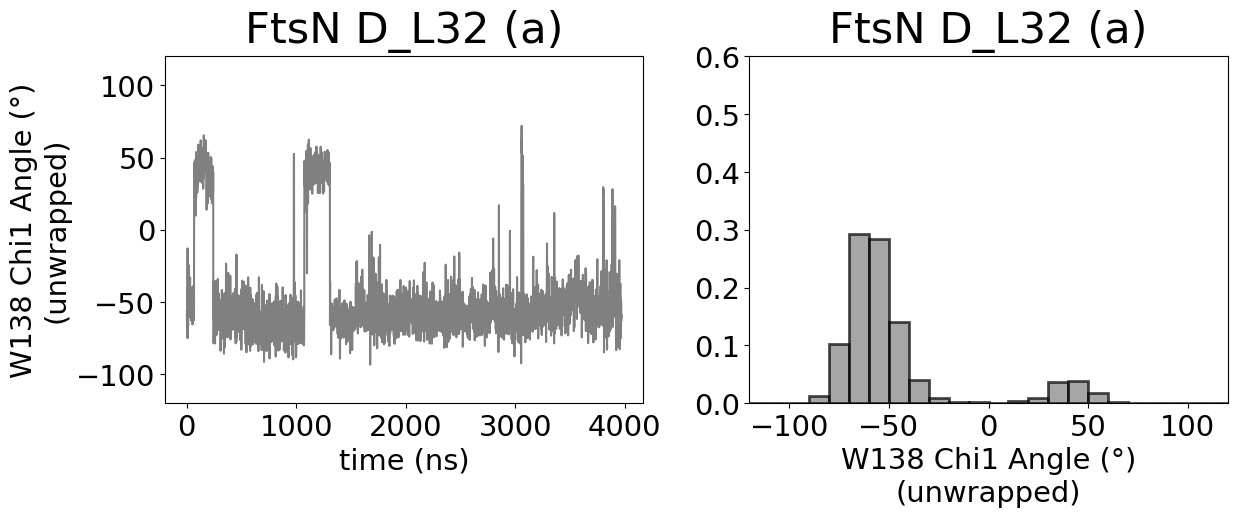

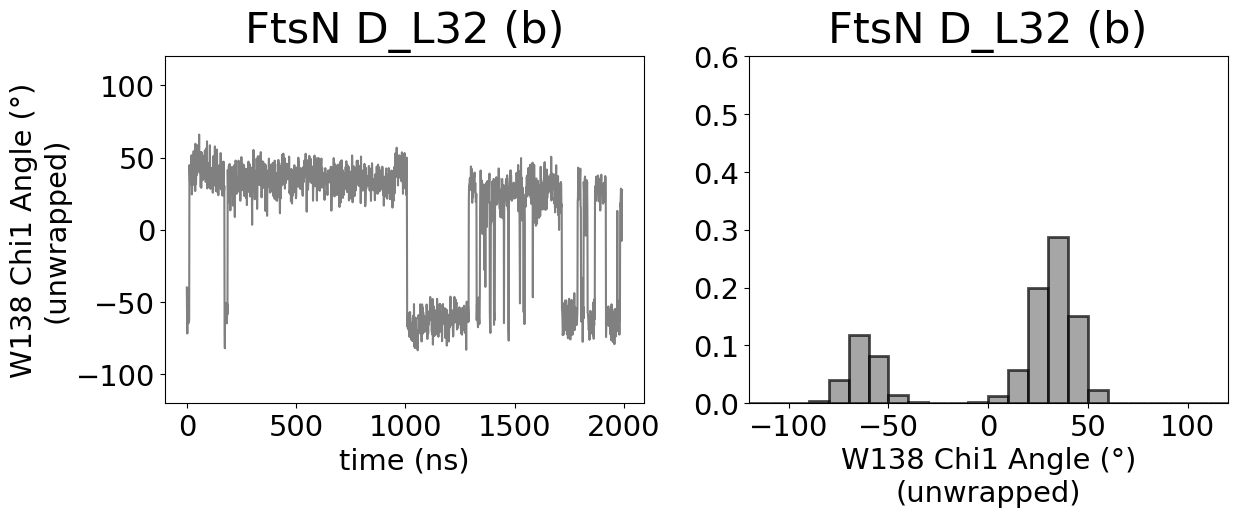

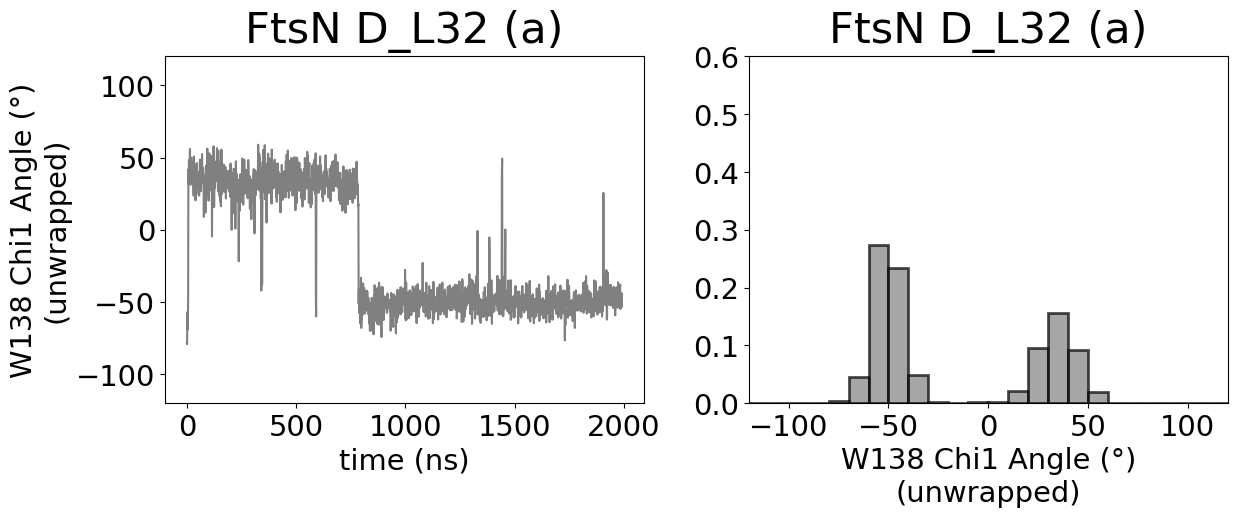

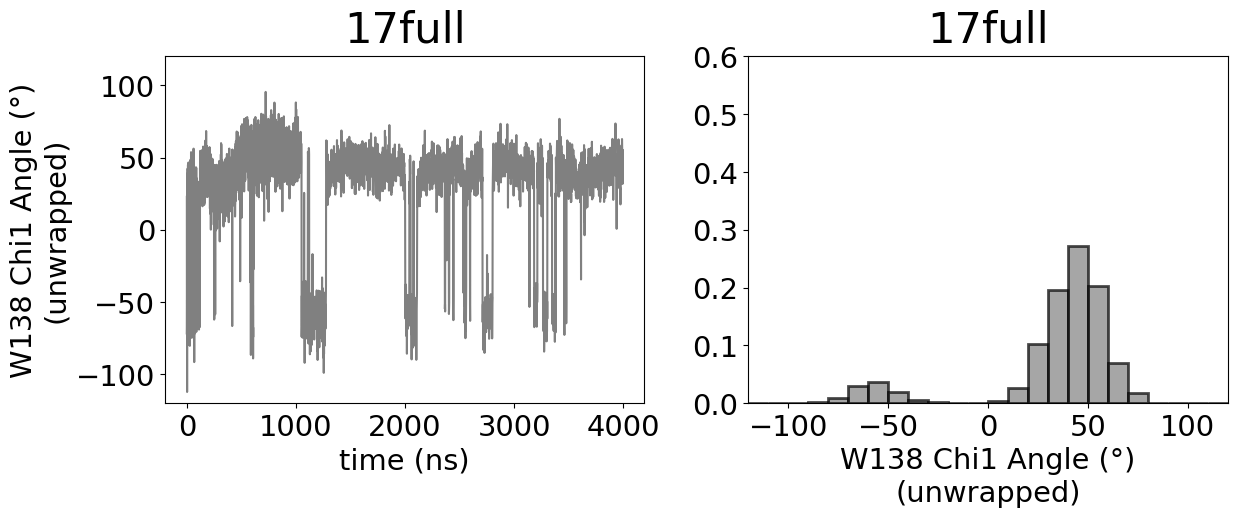

In [23]:
# Plot: time trace + histogram per simulation (for both analyses)

for a in analyses:
    short_var_name = a["short_var_name"]
    var_name = a["var_name"]
    x_lim = a["x_lim"]
    max_hist = a["max_hist"]
    scale = a["scale"]

    data_dict = all_data.get(short_var_name, {})
    if not data_dict:
        print(f"No cached data for {short_var_name}, skipping plots")
        continue

    style = DihedralPlotStyle(scale=scale, max_hist=max_hist, x_lim=x_lim)

    for sim_number, csv_path in data_dict.items():
        png_path = Path(csv_path).with_suffix(".png")

        title = sim_number
        try:
            if sim_number in sim_to_idx:
                title = label_list[sim_to_idx[sim_number]]
        except Exception:
            pass

        plot_dihedral_trace_hist(
            csv_path=csv_path,
            var_name=var_name,
            out_png_path=png_path,
            title=title,
            style=style,
        )


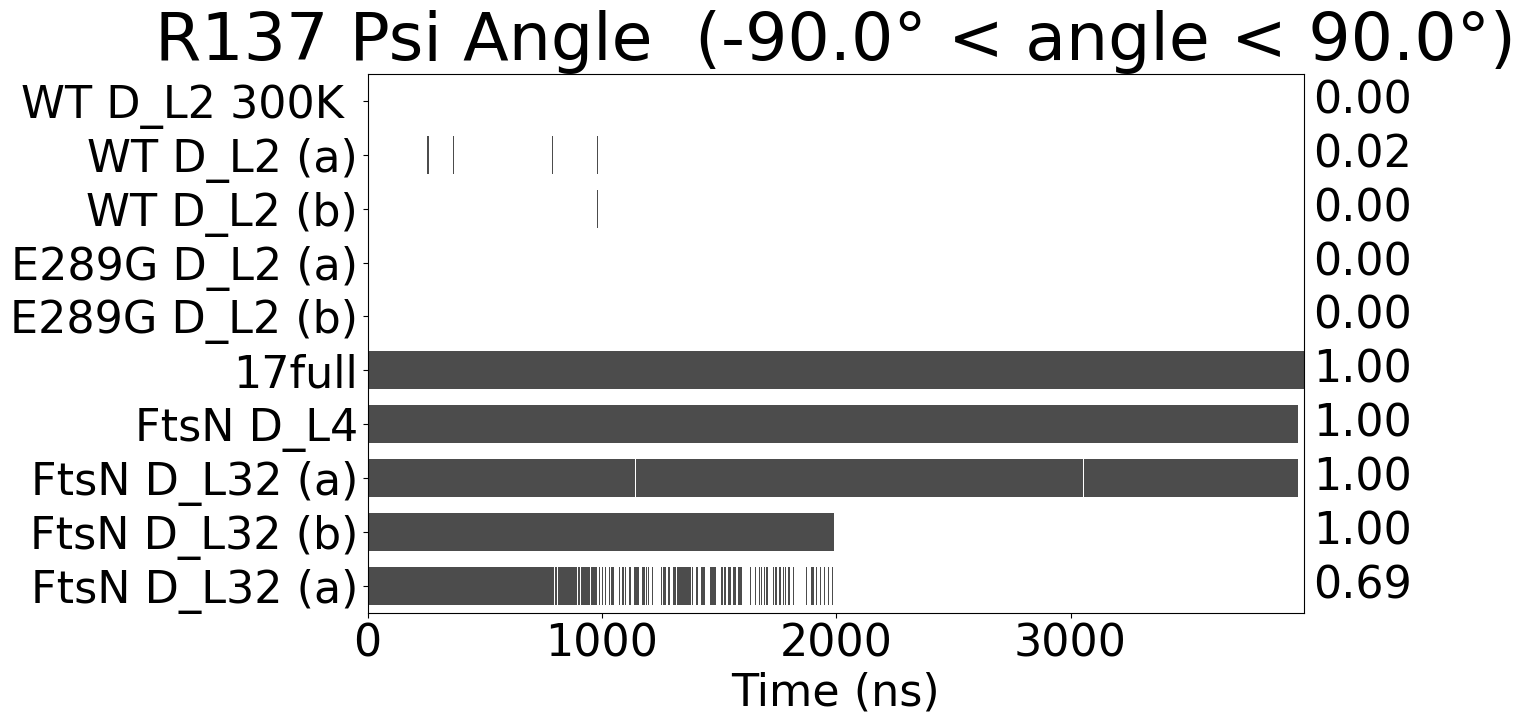

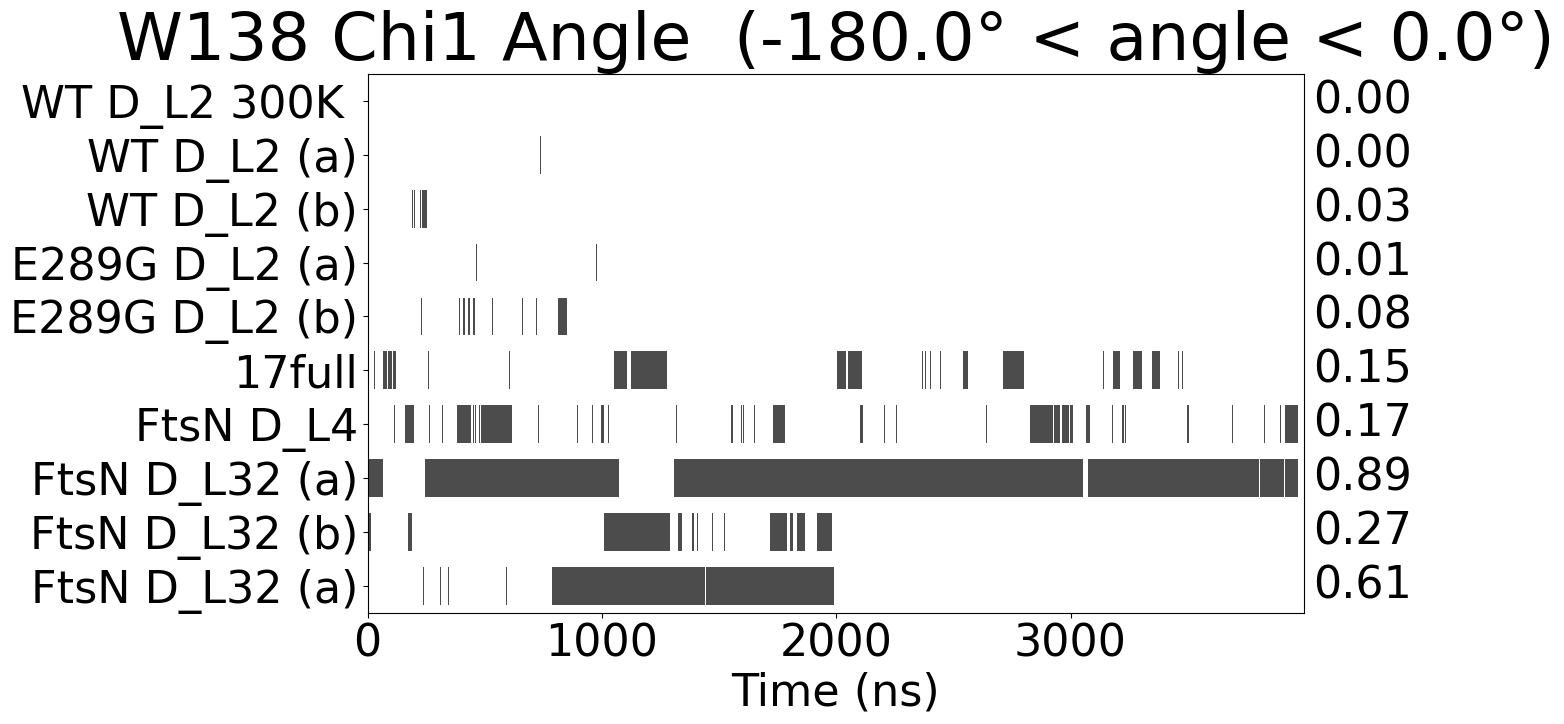

In [24]:
# Timeline summary: fraction of time in angle range (for both analyses)

# These are the paper-relevant sims from v1; the function will auto-skip missing.
paper_summary_list = ["8", "14", "14b", "15", "15b", "17full", "42", "43", "43b", "43c"]

for a in analyses:
    short_var_name = a["short_var_name"]
    var_name = a["var_name"]
    out_dir = Path(a["out_dir"]).expanduser().resolve()

    data_dict = all_data.get(short_var_name, {})
    if not data_dict:
        continue

    summary_list = [s for s in paper_summary_list if s in data_dict]
    if not summary_list:
        print(f"No summary sims present for {short_var_name}, skipping summary")
        continue

    out_png = out_dir / f"{'-'.join(summary_list)}_{short_var_name}_range_summary.png"

    if short_var_name == "R137_Psi_Angle":
        angle_range = (-90, 90)
    elif short_var_name == "W138_Chi1_Angle":
        angle_range = (-180, 0)
    else:
        raise ValueError(f"Unknown analysis: {short_var_name}")

    plot_angle_range_summary(
        data_dict=data_dict,
        out_png_path=str(out_png),
        summary_list=summary_list,
        sim_list=sims_to_load,
        label_list=label_list,
        var_name=var_name,
        angle_range=angle_range,
        style=AngleRangeSummaryStyle(scale=4.0, long_end=True),
    )


In [25]:
# (v1 compatibility cell removed)
# This notebook now runs both paper angles above.